In [1]:
# Cell 1: Import libraries and load data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, roc_curve, roc_auc_score

# Load dataset
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
# Cell 2: Check data types and missing values
print(df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("\nTarget distribution:\n", df['Churn'].value_counts())

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Missing values:
 customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
Paymen

In [3]:
# Cell 3: Clean and preprocess
df_clean = df.copy()

# Drop customerID - it's just an identifier, not predictive
df_clean = df_clean.drop(columns=['customerID'])

# Fix TotalCharges: convert to numeric, coercing blanks to NaN
df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'], errors='coerce')
print("Missing after conversion:", df_clean['TotalCharges'].isnull().sum())

# Fill those few missing values with median
df_clean['TotalCharges'] = df_clean['TotalCharges'].fillna(df_clean['TotalCharges'].median())

# Encode target variable: Yes/No -> 1/0
df_clean['Churn'] = df_clean['Churn'].map({'Yes': 1, 'No': 0})

# Encode all other categorical (object) columns using one-hot encoding
categorical_cols = df_clean.select_dtypes(include='object').columns.tolist()
print("\nCategorical columns to encode:", categorical_cols)

df_clean = pd.get_dummies(df_clean, columns=categorical_cols, drop_first=True)

print("\nFinal shape:", df_clean.shape)

Missing after conversion: 11

Categorical columns to encode: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Final shape: (7043, 31)


In [4]:
# Cell 4: Split and scale
X = df_clean.drop(columns=['Churn'])
y = df_clean['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale numerical features (tenure, MonthlyCharges, TotalCharges)
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

print("Train shape:", X_train.shape, "| Test shape:", X_test.shape)

Train shape: (5634, 30) | Test shape: (1409, 30)


In [5]:
# Cell 5: Train the model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [6]:
# Cell 6: Interpret coefficients as odds ratios
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})
coef_df['Odds_Ratio'] = np.exp(coef_df['Coefficient'])
coef_df = coef_df.sort_values(by='Odds_Ratio', ascending=False)

print(coef_df.head(10))
print("\n--- Bottom 10 (features that REDUCE churn odds) ---")
print(coef_df.tail(10))

                           Feature  Coefficient  Odds_Ratio
10     InternetService_Fiber optic     1.190576    3.288977
3                     TotalCharges     0.511378    1.667588
23             StreamingMovies_Yes     0.380384    1.462846
21                 StreamingTV_Yes     0.378872    1.460636
28  PaymentMethod_Electronic check     0.377641    1.458839
26            PaperlessBilling_Yes     0.371600    1.450052
9                MultipleLines_Yes     0.365301    1.440948
0                    SeniorCitizen     0.144638    1.155621
29      PaymentMethod_Mailed check     0.067582    1.069919
17            DeviceProtection_Yes     0.037562    1.038277

--- Bottom 10 (features that REDUCE churn odds) ---
                               Feature  Coefficient  Odds_Ratio
12  OnlineSecurity_No internet service    -0.174340    0.840011
6                       Dependents_Yes    -0.225854    0.797834
8       MultipleLines_No phone service    -0.246604    0.781450
19                     TechSupp

In [7]:
# Cell 7: Evaluate the model
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_proba)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"AUC:       {auc:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy:  0.8055
Precision: 0.6572
Recall:    0.5588
AUC:       0.8421

Confusion Matrix:
[[926 109]
 [165 209]]


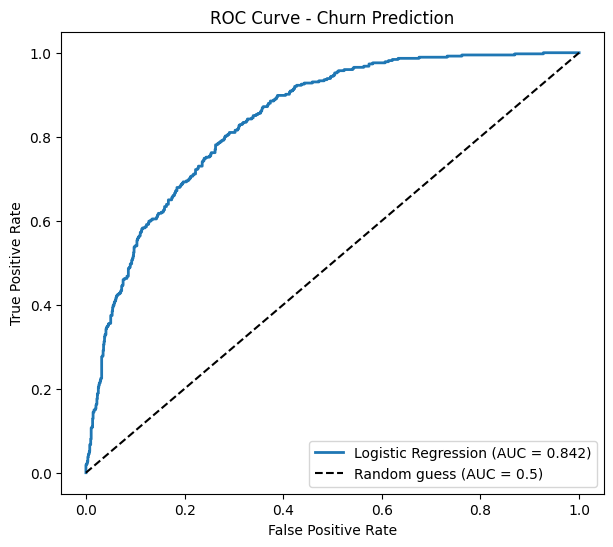

In [8]:
# Cell 8: Plot ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc:.3f})', linewidth=2)
plt.plot([0,1], [0,1], 'k--', label='Random guess (AUC = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Churn Prediction')
plt.legend()
plt.show()

In [9]:
# Cell 9: Summary
print("="*50)
print("TASK 3 SUMMARY: Logistic Regression for Binary Classification")
print("="*50)
print(f"Dataset: Telco Customer Churn ({df.shape[0]} samples, 31 features after encoding)")
print(f"Class balance: 73% No Churn / 27% Churn")
print(f"Train set: {X_train.shape[0]} | Test set: {X_test.shape[0]}")
print(f"\nAccuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"AUC:       {auc:.4f}")
print(f"\nKey insight: Contract type and tenure are the strongest predictors")
print(f"of churn. Month-to-month, low-tenure, fiber-optic customers are")
print(f"the highest-risk group. Model has higher precision than recall,")
print(f"meaning it misses some actual churners (165 false negatives).")

TASK 3 SUMMARY: Logistic Regression for Binary Classification
Dataset: Telco Customer Churn (7043 samples, 31 features after encoding)
Class balance: 73% No Churn / 27% Churn
Train set: 5634 | Test set: 1409

Accuracy:  0.8055
Precision: 0.6572
Recall:    0.5588
AUC:       0.8421

Key insight: Contract type and tenure are the strongest predictors
of churn. Month-to-month, low-tenure, fiber-optic customers are
the highest-risk group. Model has higher precision than recall,
meaning it misses some actual churners (165 false negatives).
